# RBIG Loss Functions and Convergence

This notebook explores how `AnnealedRBIG` converges and the information
measures that can be used to track training progress:

- **Maximum layers** — stop after a fixed number of layers.
- **Total Correlation (TC) reduction** — track the TC per layer and stop when
  it stops decreasing.
- **Entropy reduction** — compare the entropy before and after transformation.

The new API replaces the old `MaxLayersLoss`, `InformationLoss`, and
`NegEntropyLoss` classes with built-in convergence logic in `AnnealedRBIG`
and utility functions `entropy_reduction` and `total_correlation`.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from rbig import AnnealedRBIG, entropy_reduction, total_correlation

plt.style.use("seaborn-v0_8-paper")

/home/azureuser/localfiles/rbig/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plot_2d_joint(data, color="steelblue", title="Data"):
    _fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(data[:, 0], data[:, 1], s=1, alpha=0.3, color=color)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

## Data

2-D sin-wave distribution.

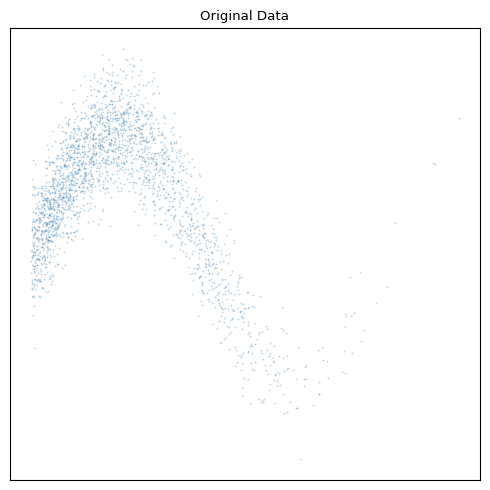

In [3]:
seed = 123
rng = np.random.RandomState(seed=seed)

num_samples = 2_500
x = np.abs(2 * rng.randn(1, num_samples))
y = np.sin(x) + 0.25 * rng.randn(1, num_samples)
data = np.vstack((x, y)).T

plot_2d_joint(data, title="Original Data")

## Strategy I — Fixed Number of Layers (`n_layers`)

The simplest stopping criterion is a hard cap on the number of layers.  This
mirrors the old `MaxLayersLoss(n_layers=N)`.

In [4]:
for n in [5, 10, 20]:
    m = AnnealedRBIG(
        n_layers=n, rotation="pca", patience=n + 1, random_state=seed
    )
    Z = m.fit_transform(data)
    tc_final = m.tc_per_layer_[-1]
    print(f"n_layers={n:3d}  → TC after last layer: {tc_final:.4f}")

n_layers=  5  → TC after last layer: -0.0069


n_layers= 10  → TC after last layer: 0.0001


n_layers= 20  → TC after last layer: 0.0002


## Strategy II — TC Convergence (`patience`)

`AnnealedRBIG` tracks the TC after each layer.  When the TC change is smaller
than `tol` for `patience` consecutive layers the fitting stops early.
This mirrors the old `InformationLoss`.

Early-stopped at layer 25


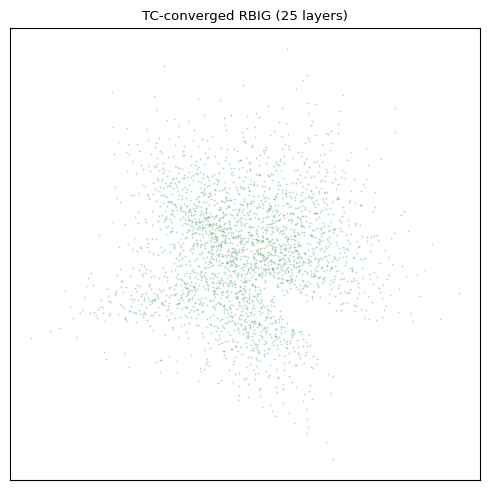

In [5]:
rbig_tc = AnnealedRBIG(
    n_layers=50,
    rotation="pca",
    patience=10,  # stop after 10 layers with negligible TC change
    tol=1e-5,
    random_state=seed,
)
rbig_tc.fit(data)
Z_tc = rbig_tc.transform(data)

print(f"Early-stopped at layer {len(rbig_tc.layers_)}")
plot_2d_joint(
    Z_tc, color="seagreen", title=f"TC-converged RBIG ({len(rbig_tc.layers_)} layers)"
)

### TC trajectory

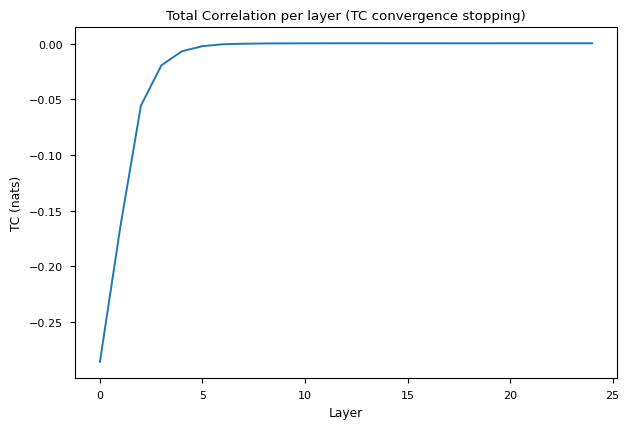

In [6]:
fig, ax = plt.subplots()
ax.plot(rbig_tc.tc_per_layer_)
ax.set_xlabel("Layer")
ax.set_ylabel("TC (nats)")
ax.set_title("Total Correlation per layer (TC convergence stopping)")
plt.tight_layout()
plt.show()

## Strategy III — Entropy Reduction

`entropy_reduction(X_before, X_after)` computes the TC reduction between two
representations.  A positive value means the transformation has reduced the
statistical dependence between features.

In [7]:
# Compare TC before and after full RBIG transformation
tc_before = total_correlation(data)
tc_after = total_correlation(Z_tc)
red = entropy_reduction(data, Z_tc)

print(f"TC before RBIG : {tc_before:.4f} nats")
print(f"TC after  RBIG : {tc_after:.4f} nats")
print(f"TC reduction   : {red:.4f} nats")

TC before RBIG : -0.1397 nats
TC after  RBIG : 0.0003 nats
TC reduction   : -0.1400 nats


## Layer-by-layer Information Reduction

We can compute the information reduction at each layer by comparing consecutive
TC values.

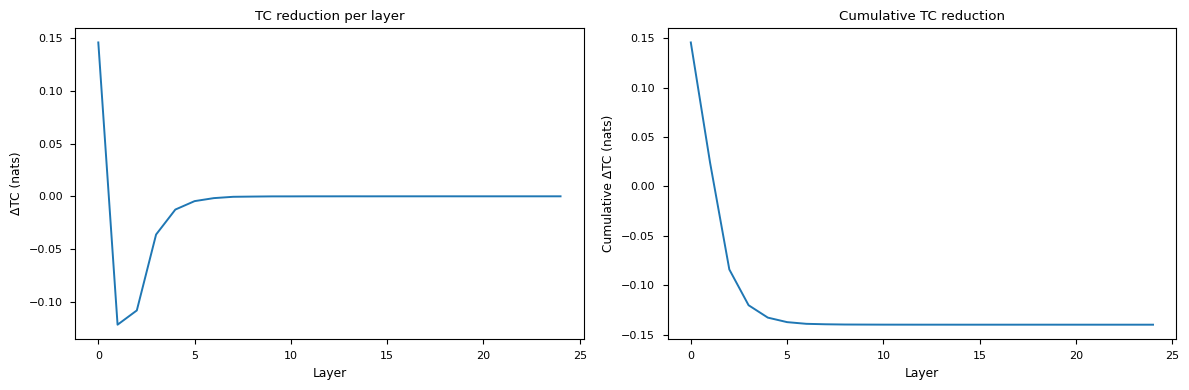

In [8]:
tc_layers = rbig_tc.tc_per_layer_

# TC reduction per layer = TC[i-1] - TC[i]  (first layer vs. original data TC)
tc_all = [tc_before, *list(tc_layers)]
tc_delta = [tc_all[i] - tc_all[i + 1] for i in range(len(tc_layers))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tc_delta)
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("ΔTC (nats)")
axes[0].set_title("TC reduction per layer")

axes[1].plot(np.cumsum(tc_delta))
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Cumulative ΔTC (nats)")
axes[1].set_title("Cumulative TC reduction")

plt.tight_layout()
plt.show()

## Negative Log-Likelihood as a Training Signal

`score_samples(X)` returns log p(x) under the RBIG model.  The negative mean
is the NLL — a natural training objective for generative models.

In [9]:
nll_before = -rbig_tc.score(data)  # NLL on training data
print(f"NLL on training data: {nll_before:.4f}")

# Entropy of the fitted distribution
h = rbig_tc.entropy()
print(f"Entropy (nats):        {h:.4f}")

NLL on training data: -23.1166
Entropy (nats):        -23.1166


## Comparison: Fewer vs. More Layers

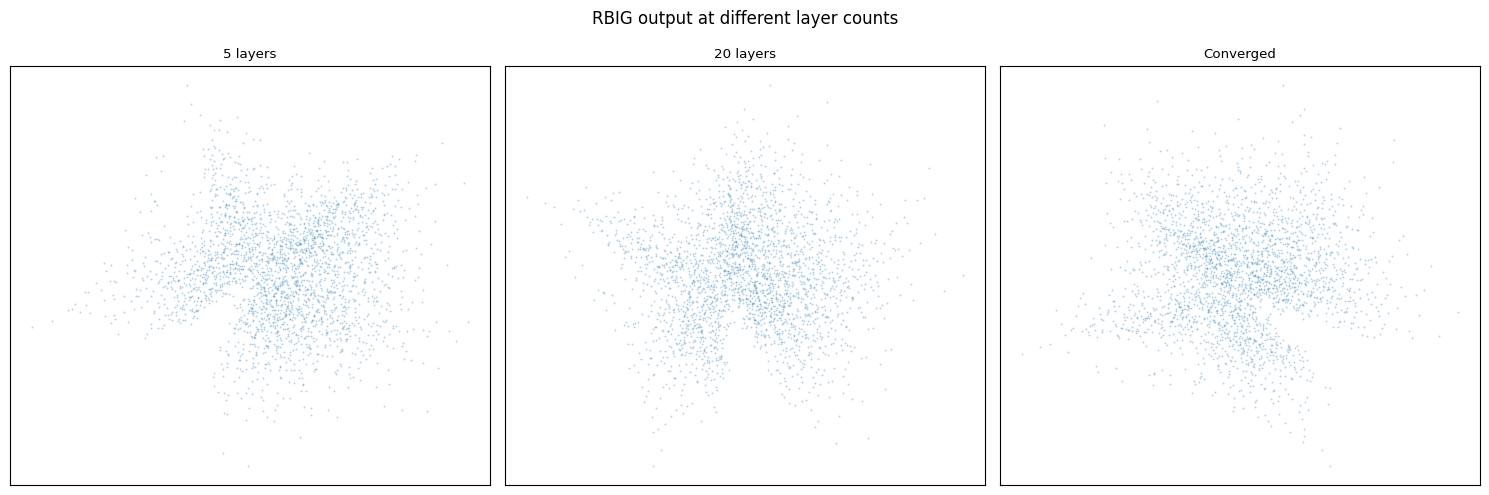

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [(5, "5 layers"), (20, "20 layers"), (len(rbig_tc.layers_), "Converged")]

for ax, (n, label) in zip(axes, configs, strict=False):
    if n == len(rbig_tc.layers_):
        Z_plot = Z_tc
    else:
        m = AnnealedRBIG(
            n_layers=n, rotation="pca", patience=n + 1, random_state=seed
        )
        Z_plot = m.fit_transform(data)
    ax.scatter(Z_plot[:, 0], Z_plot[:, 1], s=1, alpha=0.3)
    ax.set_title(label)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("RBIG output at different layer counts")
plt.tight_layout()
plt.show()

## Summary

| Old API | New API equivalent |
|---|---|
| `MaxLayersLoss(n_layers=N)` | `AnnealedRBIG(n_layers=N, patience=N+1)` |
| `InformationLoss(tol_layers=K)` | `AnnealedRBIG(n_layers=∞, patience=K)` |
| `NegEntropyLoss` | Monitor `tc_per_layer_` or `score_samples` |
| `rbig_model.losses_` | `rbig_model.tc_per_layer_` |
| `InformationLoss.calculate_loss(X, Y)` | `entropy_reduction(X, Y)` |